Домашняя работа 1


Бизнес-постановка задачи - Посторение модели, которая разделяет людей на тех, кто сможет выполнить свои кредитные обязательства, и на тех, кого ждёт дефолт.

Модели будет требоваться сначала выдавать условную вероятность, которая будет от 0 до 1, а потом будет использована пороговая функция, которая округляет до 0 или 1. То есть будет использована бинарная классификация.

Для решения данной задачи будет использован датасет:   
https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients  
ID - ID Клиента

LIMIT_BAL - Сумма выданного кредита

SEX - Пол (1 - мужчина, 2 - женщина)

EDUCATION - Образование(1=школа, 2=университет, 3=старшая школа, 4=другое, 5=неизвестно, 6=неизвестно)

MARRIAGE - Статус (1=женат, 2=одинок, 3=другое)

AGE - Возраст  

PAY_0 — статус погашения в сентябре 2005 года

(-1 — платёж внесён вовремя,

1 — задержка на 1 месяц,

2 — задержка на 2 месяца,

…  

8 — задержка на 8 месяцев,  

9 — задержка на 9 месяцев и более)

PAY_2 — статус погашения в августе 2005 года (та же шкала)  

PAY_3 — статус погашения в июле 2005 года (та же шкала)

PAY_4 — статус погашения в июне 2005 года (та же шкала)

PAY_5 — статус погашения в мае 2005 года (та же шкала)  

PAY_6 — статус погашения в апреле 2005 года (та же шкала)

BILL_AMT1 — сумма счёта в сентябре 2005 года (в новых тайваньских долларах NT$)   

BILL_AMT2 — сумма счёта в августе 2005 года (NT$)  

BILL_AMT3 — сумма счёта в июле 2005 года (NT$)  

BILL_AMT4 — сумма счёта в июне 2005 года (NT$)

BILL_AMT5 — сумма счёта в мае 2005 года (NT$)

BILL_AMT6 — сумма счёта в апреле 2005 года (NT$)   

PAY_AMT1 — сумма платежа в сентябре 2005 года (NT$)  

PAY_AMT2 — сумма платежа в августе 2005 года (NT$)

PAY_AMT3 — сумма платежа в июле 2005 года (NT$)

PAY_AMT4 — сумма платежа в июне 2005 года (NT$)

PAY_AMT5 — сумма платежа в мае 2005 года (NT$)

PAY_AMT6 — сумма платежа в апреле 2005 года (NT$)
  
default.payment.next.month — факт дефолта в следующем месяце
(1 — да, 0 — нет)

Метрики:  
ExpectedCost - это метрика позволяет оперделять лучшее пороговое значение.  
MCC - так как у нас очень большой дисбаланс классов.  
AUC ROC - потому что очень важна способность модели разделять классы.

EDA

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/content/sample_data/UCI_Credit_Card.csv')  # часто первая строка — заголовок
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


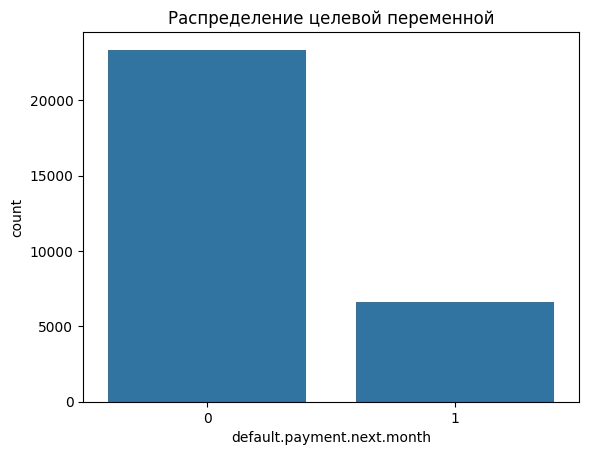

,proportion
default.payment.next.month,
0,0.7788
1,0.2212


In [15]:
sns.countplot(x='default.payment.next.month', data=df)
plt.title('Распределение целевой переменной')
plt.show()

df['default.payment.next.month'].value_counts(normalize=True)

Есть дисбаланс классов. 0.22 и 0.78.

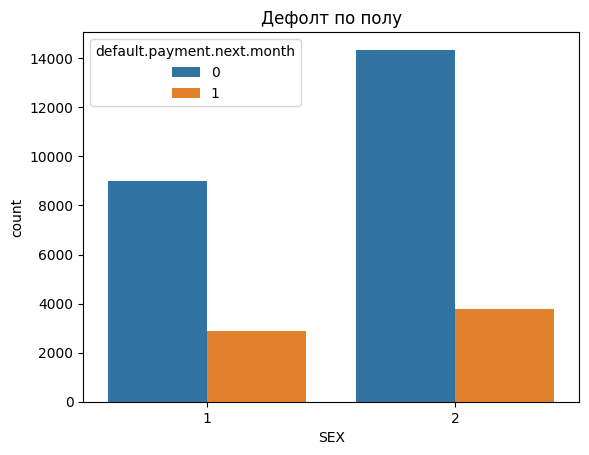

In [18]:
sns.countplot(x='SEX', hue='default.payment.next.month', data=df)
plt.title('Дефолт по полу')
plt.show()

Есть различия в доле делофтов между группами.

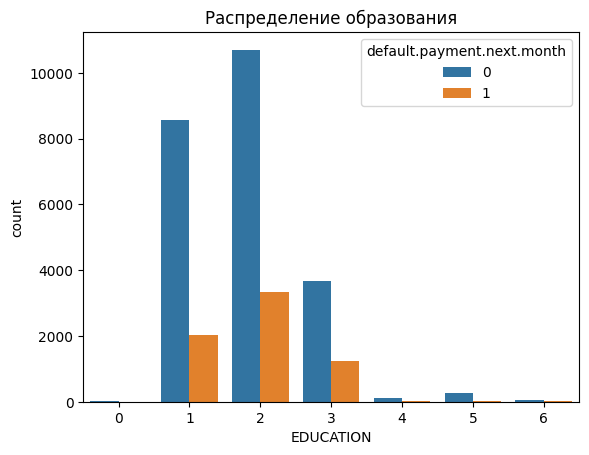

In [20]:
sns.countplot(x='EDUCATION',hue='default.payment.next.month', data=df)
plt.title('Распределение образования')
plt.show()

Некоторые категории слишком маленькие, возможно стоит их объединить.

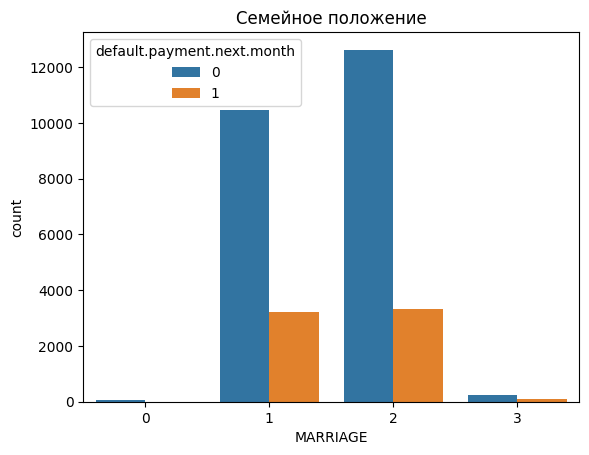

In [23]:
sns.countplot(x='MARRIAGE',hue='default.payment.next.month', data=df)
plt.title('Семейное положение')
plt.show()

Есть различие в долях между группами, возможно это полезная метрика.

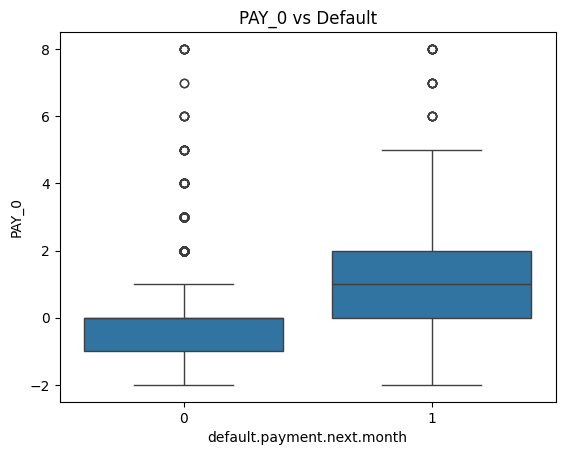

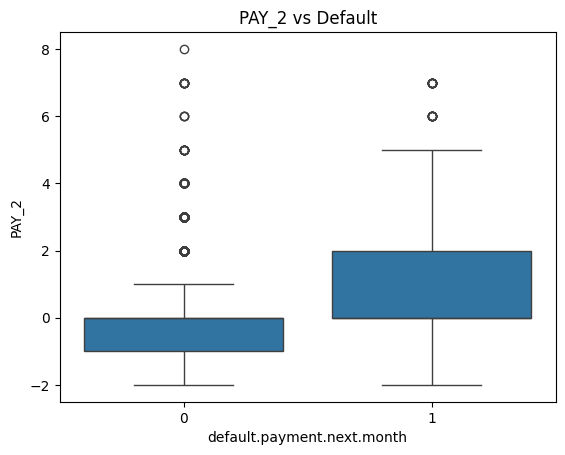

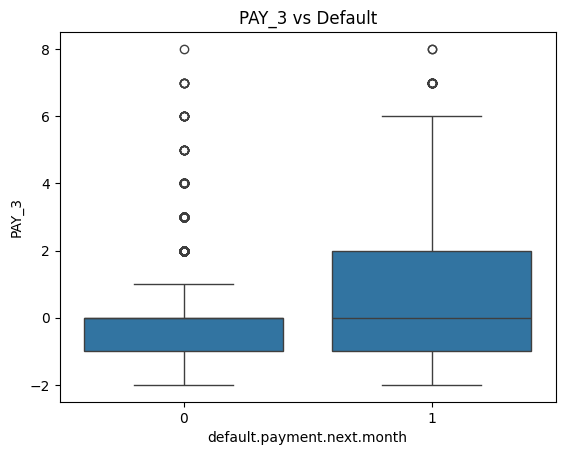

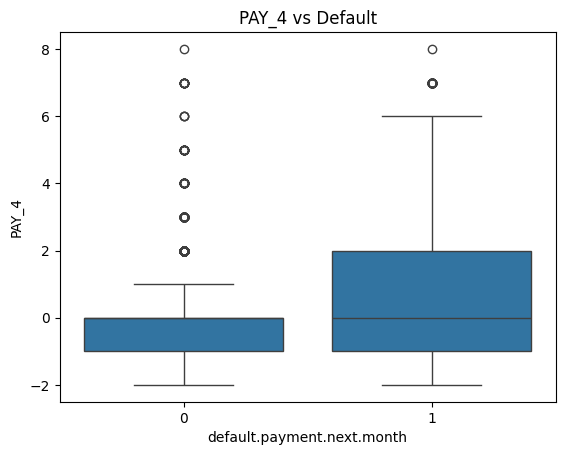

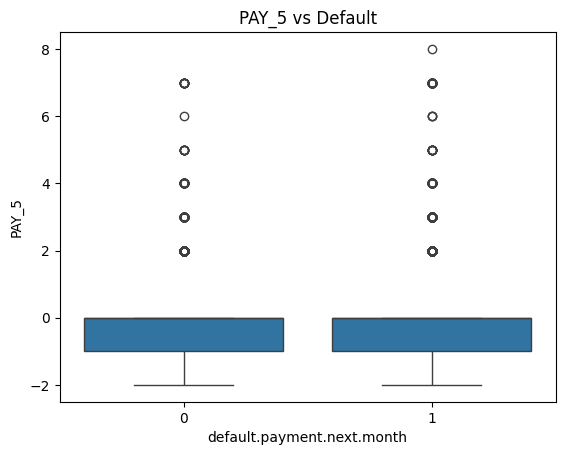

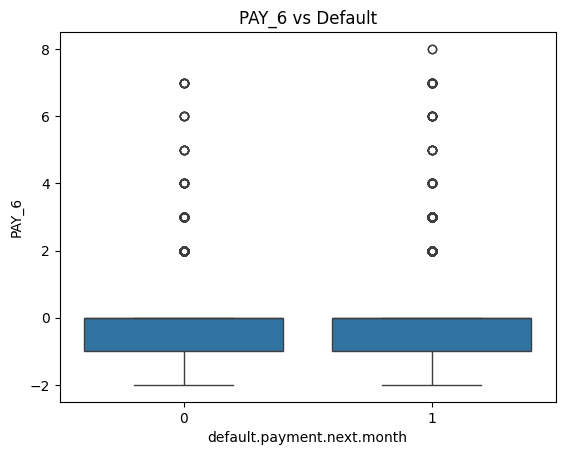

In [24]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

for col in pay_cols:
    sns.boxplot(x='default.payment.next.month', y=col, data=df)
    plt.title(f'{col} vs Default')
    plt.show()

скорее всего серия этих метрик самая важная, потому что наблюдается сильная корреляция до pay_4/

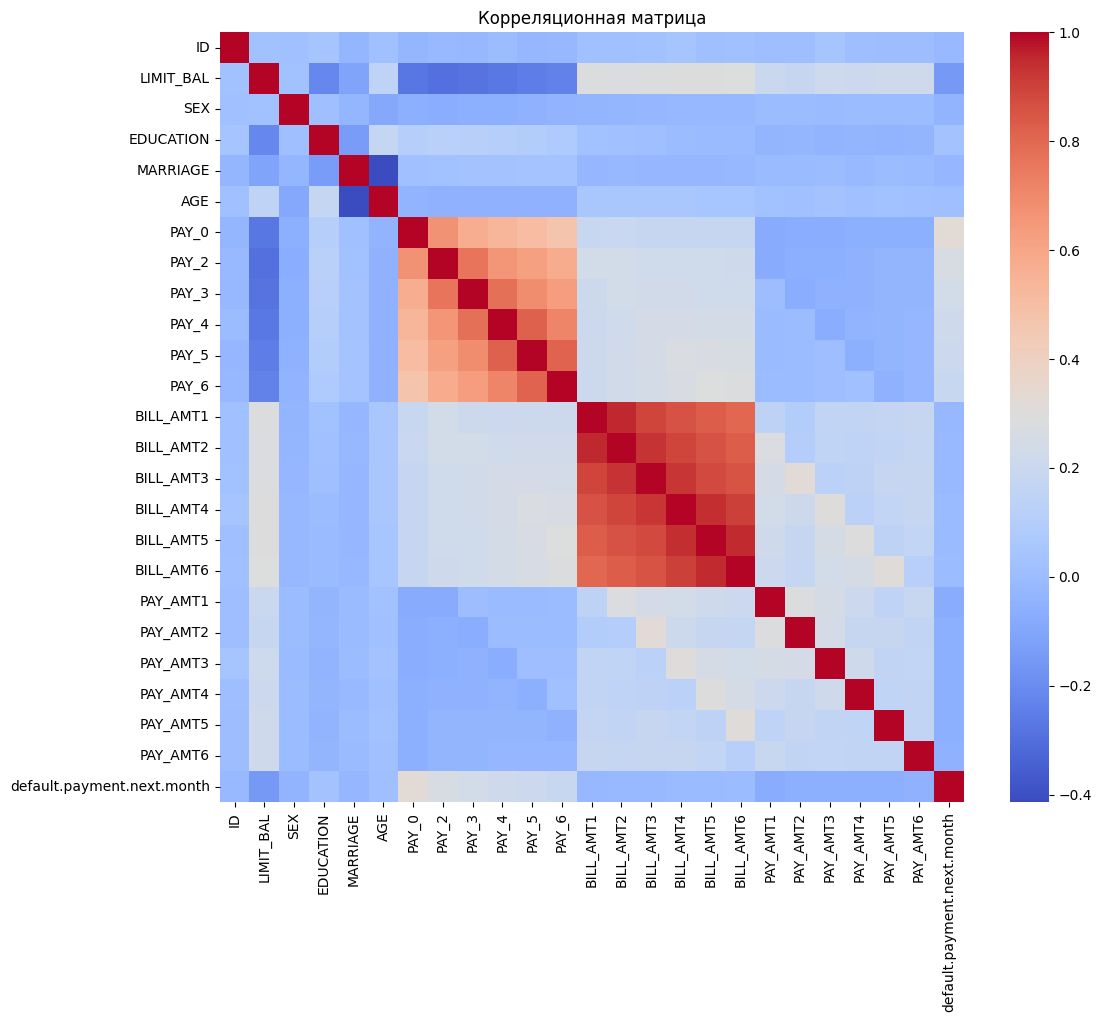

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

Есть сильная коллеряция внутри pay и bill, но они связаны между собой по опредлениям, а больше мультиколлениарности нет.

## Итоги
Есть дисбаланс классов 22%.  
В категориальных данных есть нерелевантные значения, возможно стоит объединять категории. Или стоит как в случае образование отсортировать категории по сложности получения.  
Скорее всего серия перменный pay самая важная.  
Есть данные за временной период, поэтому возможно создание чего нового из этого.